In [40]:
import sys

sys.path += ['..']

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import itertools as it
from picketty.agent.laborer import Laborer

In [42]:
def random_laborer():
    return Laborer(
        wealth=np.random.lognormal(0, 1),
        needs=np.random.uniform(0, 1),
        wealth_factor=np.random.lognormal(0, 1),
        discount_rate=np.random.uniform(0, 1),
        skill=np.random.lognormal(0, 1),
    )

In [77]:
laborer = random_laborer()
prices = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
salaries = np.linspace(0, 100.0, 21)
df = pd.DataFrame([
    {"price": price, "salary": salary, "labor_ratio": laborer.get_optimal_labor_ratio(salary, price).real}
    for price, salary in it.product(prices, salaries)
]).pivot_table(index="price", columns="salary", values="labor_ratio")

df

/Users/rafael.calsaverini/dev/personal/sandbox.py/10_econ_simulations/Picketty/notebooks/../picketty/agent/laborer.py:35: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - 2 * (base_salary / salary) * (sqrt(1 + salary / base_salary) - 1)
/Users/rafael.calsaverini/dev/personal/sandbox.py/10_econ_simulations/Picketty/notebooks/../picketty/agent/laborer.py:35: RuntimeWarning: invalid value encountered in multiply
  return 1 - 2 * (base_salary / salary) * (sqrt(1 + salary / base_salary) - 1)


salary,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0,85.0,90.0,95.0,100.0
price,,,,,,,,,,,,,,,,,,,,
0.25,0.659438,0.744180,0.785415,0.811145,0.829212,0.842819,0.853554,0.862312,0.869636,0.875883,0.881294,0.886042,0.890253,0.894021,0.897420,0.900507,0.903326,0.905916,0.908304,0.910517
0.50,0.563820,0.665033,0.716178,0.748687,0.771778,0.789310,0.803227,0.814633,0.824210,0.832404,0.839522,0.845782,0.851346,0.856334,0.860841,0.864939,0.868688,0.872135,0.875319,0.878271
1.00,0.462670,0.576045,0.636213,0.675395,0.703653,0.725337,0.742688,0.756999,0.769076,0.779453,0.788500,0.796482,0.803595,0.809988,0.815776,0.821050,0.825883,0.830334,0.834450,0.838273
2.00,0.368111,0.486394,0.552894,0.597483,0.630241,0.655706,0.676283,0.693385,0.707909,0.720454,0.731439,0.741168,0.749867,0.757709,0.764827,0.771329,0.777300,0.782809,0.787913,0.792662
4.00,0.291763,0.407876,0.477109,0.524985,0.560858,0.589138,0.612232,0.631587,0.648136,0.662511,0.675159,0.686408,0.696504,0.705633,0.713945,0.721556,0.728561,0.735039,0.741053,0.746657
8.00,0.238586,0.348911,0.418077,0.467235,0.504729,0.534667,0.559352,0.580200,0.598137,0.613800,0.627644,0.640003,0.651132,0.661227,0.670441,0.678899,0.686702,0.693931,0.700654,0.706930
16.00,0.205878,0.310453,0.378411,0.427702,0.465806,0.496526,0.522045,0.543725,0.562468,0.578901,0.593476,0.606526,0.618309,0.629021,0.638819,0.647830,0.656157,0.663883,0.671079,0.677805


<AxesSubplot: xlabel='salary'>

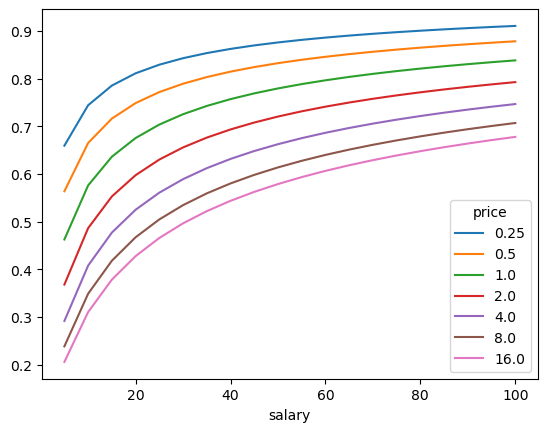

In [78]:
df.T.plot()